# NLPstudy_03 - Transformer Attention Head 역할 분화 분석 실험

- **Dataset:**  opus100 Portuguese → English (전체 1,000,000개 / 실제 학습 사용: 훈련 5,000개, 검증 500개)
- **Framework:** TensorFlow 2.x


| 실험 | 내용 |
|:---:|---|
| **실험 A** | Attention Head 패턴 시각화 |
| **실험 B** | Head 수 변화에 따른 성능 비교 |
| **실험 C** | Head Pruning (학습 후 불필요한 Head 제거) |

---
## 0. 환경 설정 및 라이브러리 설치

In [1]:
# Cell 1: 환경 설정 및 라이브러리 설치
!pip uninstall -y -q tensorflow keras tensorflow-estimator tensorflow-text
!pip install -q -U tensorflow tensorflow-text tensorflow-datasets
!pip install -q nltk

import logging
import time
import gc
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import tensorflow as tf
import tensorflow_text
import nltk
nltk.download('punkt_tab')

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tensorflow.keras.callbacks import EarlyStopping

print("GPU 사용 가능:", tf.config.list_physical_devices("GPU"))
print("TensorFlow 버전:", tf.__version__)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompatible.


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


GPU 사용 가능: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow 버전: 2.20.0


---
## 1. 데이터 로드 및 토크나이저 설정

In [2]:
# Cell 2: 데이터 로드 및 토크나이저 설정
# 포르투갈어-영어 번역 데이터셋 로드
# 원래 TED Talks(52,000개) 대신 opus100 사용 (소스 서버 오류로 대체)
# 실제 학습에는 train 5,000개 / validation 500개만 사용 (실험 결과 동일)

!pip install -q datasets
from datasets import load_dataset

# HuggingFace 데이터 로드
hf_dataset = load_dataset("opus100", "en-pt")

# tf.data.Dataset 형식으로 변환
def hf_to_tf(split):
    pts = [ex['translation']['pt'] for ex in hf_dataset[split]]
    ens = [ex['translation']['en'] for ex in hf_dataset[split]]
    return tf.data.Dataset.from_tensor_slices((pts, ens))

train_examples = hf_to_tf('train')
val_examples   = hf_to_tf('validation')

print("train 샘플 수:",      len(hf_dataset['train']))
print("validation 샘플 수:", len(hf_dataset['validation']))

# 토크나이저 다운로드
model_name = 'ted_hrlr_translate_pt_en_converter'
tf.keras.utils.get_file(
    f'{model_name}.zip',
    f'https://storage.googleapis.com/download.tensorflow.org/models/{model_name}.zip',
    cache_dir='.', cache_subdir='', extract=True
)

# 실제 경로로 로드
tokenizers = tf.saved_model.load(
    './ted_hrlr_translate_pt_en_converter_extracted/ted_hrlr_translate_pt_en_converter'
)

print("포르투갈어 어휘 크기:", tokenizers.pt.get_vocab_size().numpy())
print("영어 어휘 크기:",       tokenizers.en.get_vocab_size().numpy())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train 샘플 수: 1000000
validation 샘플 수: 2000
포르투갈어 어휘 크기: 7765
영어 어휘 크기: 7010


---
## 2. 데이터 파이프라인 구축

In [3]:
# Cell 3: 데이터 파이프라인 구축
# en_inputs = [START, I, drank, coffee]
# en_labels =        [I, drank, coffee, END]  ← 한 칸 shift → 다음 단어 예측

MAX_TOKENS  = 64
BUFFER_SIZE = 20000
BATCH_SIZE  = 128

def prepare_batch(pt, en):
    """배치 데이터를 모델 입력 형식으로 변환"""
    pt = tokenizers.pt.tokenize(pt)
    pt = pt[:, :MAX_TOKENS]
    pt = pt.to_tensor()  # ragged → dense (0 패딩)

    en = tokenizers.en.tokenize(en)
    en = en[:, :(MAX_TOKENS + 1)]
    en_inputs = en[:, :-1].to_tensor()  # [END] 제거
    en_labels = en[:,  1:].to_tensor()  # [START] 제거

    return (pt, en_inputs), en_labels

def make_batches(ds, num_samples=5000):
    """tf.data.Dataset을 학습용 배치로 변환"""
    return (
        ds
        .take(num_samples)
        .shuffle(BUFFER_SIZE)
        .batch(BATCH_SIZE)
        .map(prepare_batch, tf.data.AUTOTUNE)
        .prefetch(buffer_size=tf.data.AUTOTUNE)
    )

train_batches = make_batches(train_examples, num_samples=3000) # (수정) 5000 -> 3000
val_batches   = make_batches(val_examples,   num_samples=300) # (수정) 500 -> 300

# 데이터 형태 확인
for (pt, en), en_labels in train_batches.take(1):
    print(f'포르투갈어 입력 shape: {pt.shape}')
    print(f'영어 입력 shape:       {en.shape}')
    print(f'영어 레이블 shape:     {en_labels.shape}')
    break

포르투갈어 입력 shape: (128, 64)
영어 입력 shape:       (128, 64)
영어 레이블 shape:     (128, 64)


---
## 3. Positional Encoding

In [4]:
# Cell 4: Positional Encoding
# Transformer는 모든 단어를 동시에 처리 → 순서 정보가 없음
# sin/cos 함수로 각 위치마다 고유한 벡터 생성 → Embedding에 더함
# 짝수 차원: sin, 홀수 차원: cos

def positional_encoding(length, depth):
    """sin/cos 기반 위치 인코딩 생성"""
    depth = depth / 2
    positions = np.arange(length)[:, np.newaxis]  # (seq, 1)
    depths    = np.arange(depth)[np.newaxis, :] / depth  # (1, depth)

    angle_rates = 1 / (10000 ** depths)  # 주파수: 10000^(2i/d_model)
    angle_rads  = positions * angle_rates

    pos_encoding = np.concatenate(
        [np.sin(angle_rads), np.cos(angle_rads)], axis=-1
    )
    return tf.cast(pos_encoding, dtype=tf.float32)

---
## 4. Positional Embedding Layer

In [5]:
# Cell 5: Positional Embedding Layer
# 토큰 Embedding + Positional Encoding을 합치는 레이어
# sqrt(d_model)을 곱해 임베딩과 위치 인코딩의 스케일을 맞춤 (논문 Section 3.4)

class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.d_model = d_model
        self.embedding = tf.keras.layers.Embedding(
            vocab_size, d_model, mask_zero=True
        )
        self.pos_encoding = positional_encoding(length=2048, depth=d_model)

    def compute_mask(self, *args, **kwargs):
        return self.embedding.compute_mask(*args, **kwargs)

    def call(self, x):
        length = tf.shape(x)[1]
        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))  # 스케일 맞춤
        x = x + self.pos_encoding[tf.newaxis, :length, :]
        return x

---
## 5. Attention Layers (Base / GlobalSelf / CausalSelf / Cross)

In [6]:
# Cell 6: Attention Layers
# ┌──────────────────────┬──────────┬───────────────────┬────────────────────────┐
# │ 클래스               │ 위치     │ Q/K/V 출처        │ 역할                   │
# ├──────────────────────┼──────────┼───────────────────┼────────────────────────┤
# │ GlobalSelfAttention  │ Encoder  │ 모두 입력(x)      │ 입력 문장 내 단어 관계 │
# │ CausalSelfAttention  │ Decoder  │ 입력(x) + 마스킹  │ 미래 단어 차단         │
# │ CrossAttention       │ Decoder  │ Q=Dec, K/V=Enc    │ 원문 어느 부분 집중    │
# └──────────────────────┴──────────┴───────────────────┴────────────────────────┘
# return_attention_scores=True → Head별 가중치 저장 (실험 A, C에서 활용)

class BaseAttention(tf.keras.layers.Layer):
    """모든 Attention 레이어의 공통 부모 클래스"""
    def __init__(self, **kwargs):
        super().__init__()
        self.mha       = tf.keras.layers.MultiHeadAttention(**kwargs)
        self.layernorm = tf.keras.layers.LayerNormalization()
        self.add       = tf.keras.layers.Add()

class GlobalSelfAttention(BaseAttention):
    """Encoder용 Self-Attention — Q, K, V 모두 같은 입력"""
    def call(self, x):
        attn_output, attn_scores = self.mha(
            query=x, value=x, key=x,
            return_attention_scores=True
        )
        self.last_attn_scores = attn_scores
        x = self.add([x, attn_output])
        x = self.layernorm(x)
        return x

class CausalSelfAttention(BaseAttention):
    """Decoder용 Masked Self-Attention — 미래 토큰 차단"""
    def call(self, x):
        attn_output, attn_scores = self.mha(
            query=x, value=x, key=x,
            use_causal_mask=True,
            return_attention_scores=True
        )
        self.last_attn_scores = attn_scores
        x = self.add([x, attn_output])
        x = self.layernorm(x)
        return x

class CrossAttention(BaseAttention):
    """Decoder의 Encoder-Decoder Attention — Query: Decoder, Key/Value: Encoder"""
    def call(self, x, context):
        attn_output, attn_scores = self.mha(
            query=x, key=context, value=context,
            return_attention_scores=True
        )
        self.last_attn_scores = attn_scores
        x = self.add([x, attn_output])
        x = self.layernorm(x)
        return x

---
## 6. Feed Forward Network

In [7]:
# Cell 7: Feed Forward Network
# Attention이 단어 간 관계를 파악한 후 → FFN이 각 단어 표현을 더 풍부하게 변환
# 비유: Attention = 팀 회의(정보 공유),  FFN = 개인 학습(정보 내재화)
# 구조: Dense(d_model→dff) + ReLU + Dense(dff→d_model) + Dropout

class FeedForward(tf.keras.layers.Layer):
    def __init__(self, d_model, dff, dropout_rate=0.1):
        super().__init__()
        self.seq = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model),
            tf.keras.layers.Dropout(dropout_rate)
        ])
        self.add        = tf.keras.layers.Add()
        self.layer_norm = tf.keras.layers.LayerNormalization()

    def call(self, x):
        x = self.add([x, self.seq(x)])  # 잔차 연결
        x = self.layer_norm(x)
        return x

---
## 7. Encoder Layer & Encoder

In [8]:
# Cell 8: Encoder Layer 및 Encoder
# EncoderLayer = GlobalSelfAttention → FeedForward
# Encoder = PositionalEmbedding + Dropout + EncoderLayer × N

class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, *, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.self_attention = GlobalSelfAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout_rate
        )
        self.ffn = FeedForward(d_model, dff, dropout_rate)

    def call(self, x):
        x = self.self_attention(x)
        x = self.ffn(x)
        return x

class Encoder(tf.keras.layers.Layer):
    def __init__(self, *, num_layers, d_model, num_heads,
                 dff, vocab_size, dropout_rate=0.1):
        super().__init__()
        self.d_model    = d_model
        self.num_layers = num_layers
        self.pos_embedding = PositionalEmbedding(vocab_size=vocab_size, d_model=d_model)
        self.enc_layers = [
            EncoderLayer(d_model=d_model, num_heads=num_heads,
                         dff=dff, dropout_rate=dropout_rate)
            for _ in range(num_layers)
        ]
        self.dropout = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x):
        x = self.pos_embedding(x)
        x = self.dropout(x)
        for enc_layer in self.enc_layers:
            x = enc_layer(x)
        return x

---
## 8. Decoder Layer & Decoder

In [9]:
# Cell 9: Decoder Layer 및 Decoder
# DecoderLayer = CausalSelfAttention → CrossAttention → FeedForward
# Encoder보다 CrossAttention이 추가됨

class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, *, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.causal_self_attention = CausalSelfAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout_rate
        )
        self.cross_attention = CrossAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout_rate
        )
        self.ffn = FeedForward(d_model, dff, dropout_rate)

    def call(self, x, context):
        x = self.causal_self_attention(x)
        x = self.cross_attention(x, context)
        self.last_attn_scores = self.cross_attention.last_attn_scores
        x = self.ffn(x)
        return x

class Decoder(tf.keras.layers.Layer):
    def __init__(self, *, num_layers, d_model, num_heads,
                 dff, vocab_size, dropout_rate=0.1):
        super(Decoder, self).__init__()
        self.d_model    = d_model
        self.num_layers = num_layers
        self.pos_embedding = PositionalEmbedding(vocab_size=vocab_size, d_model=d_model)
        self.dropout    = tf.keras.layers.Dropout(dropout_rate)
        self.dec_layers = [
            DecoderLayer(d_model=d_model, num_heads=num_heads,
                         dff=dff, dropout_rate=dropout_rate)
            for _ in range(num_layers)
        ]
        self.last_attn_scores = None

    def call(self, x, context):
        x = self.pos_embedding(x)
        x = self.dropout(x)
        for dec_layer in self.dec_layers:
            x = dec_layer(x, context)
        self.last_attn_scores = self.dec_layers[-1].last_attn_scores
        return x

---
## 9. Transformer 모델

In [10]:
# Cell 10: Transformer 모델
# 구조: Encoder + Decoder + Final Dense Layer
# Final Dense: Decoder 출력 → 어휘 크기로 변환 → 다음 단어 확률 분포

class Transformer(tf.keras.Model):
    def __init__(self, *, num_layers, d_model, num_heads, dff,
                 input_vocab_size, target_vocab_size, dropout_rate=0.1):
        super().__init__()
        self.encoder = Encoder(
            num_layers=num_layers, d_model=d_model, num_heads=num_heads,
            dff=dff, vocab_size=input_vocab_size, dropout_rate=dropout_rate
        )
        self.decoder = Decoder(
            num_layers=num_layers, d_model=d_model, num_heads=num_heads,
            dff=dff, vocab_size=target_vocab_size, dropout_rate=dropout_rate
        )
        self.final_layer = tf.keras.layers.Dense(target_vocab_size)

    def call(self, inputs):
        context, x = inputs
        context = self.encoder(context)
        x       = self.decoder(x, context)
        logits  = self.final_layer(x)
        try:
            del logits._keras_mask
        except AttributeError:
            pass
        return logits

---
## 10. Loss, Metric, Learning Rate Schedule

In [11]:
# Cell 11: Loss, Metric, Learning Rate Schedule
# masked_loss / masked_accuracy: 패딩 토큰(0)을 무시
# CustomSchedule: 논문의 warmup LR 스케줄 (warmup 구간 선형↑, 이후 sqrt↓)

def masked_loss(label, pred):
    mask = label != 0
    loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True, reduction='none'
    )
    loss = loss_object(label, pred)
    mask = tf.cast(mask, dtype=loss.dtype)
    loss *= mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(label, pred):
    pred  = tf.argmax(pred, axis=2)
    label = tf.cast(label, pred.dtype)
    match = label == pred
    mask  = label != 0
    match = match & mask
    match = tf.cast(match, dtype=tf.float32)
    mask  = tf.cast(mask,  dtype=tf.float32)
    return tf.reduce_sum(match) / tf.reduce_sum(mask)

class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    """Transformer 논문의 학습률 스케줄
    공식: lr = d_model^(-0.5) * min(step^(-0.5), step * warmup^(-1.5))
    """
    def __init__(self, d_model, warmup_steps=2000):
        super().__init__()
        self.d_model       = tf.cast(d_model, tf.float32)
        self.warmup_steps  = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, dtype=tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

---
## 11. 번역기 (Translator, 추론용)

In [12]:
# Cell 12: 번역기 (추론용)
# Auto-regressive 방식: <START> 토큰부터 시작 → 한 단어씩 생성 → <END> 나올 때까지

class Translator(tf.Module):
    def __init__(self, tokenizers, transformer):
        self.tokenizers  = tokenizers
        self.transformer = transformer

    def __call__(self, sentence, max_length=MAX_TOKENS):
        assert isinstance(sentence, tf.Tensor)
        if len(sentence.shape) == 0:
            sentence = sentence[tf.newaxis]

        sentence      = self.tokenizers.pt.tokenize(sentence).to_tensor()
        encoder_input = sentence

        start_end = self.tokenizers.en.tokenize([''])[0]
        start = start_end[0][tf.newaxis]
        end   = start_end[1][tf.newaxis]

        output_array = tf.TensorArray(dtype=tf.int64, size=0, dynamic_size=True)
        output_array = output_array.write(0, start)

        for i in tf.range(max_length):
            output      = tf.transpose(output_array.stack())
            predictions = self.transformer((encoder_input, output), training=False)
            predictions = predictions[:, -1:, :]
            predicted_id = tf.argmax(predictions, axis=-1)
            output_array = output_array.write(i + 1, predicted_id[0])
            if predicted_id == end:
                break

        output = tf.transpose(output_array.stack())
        text   = self.tokenizers.en.detokenize(output)[0]
        tokens = self.tokenizers.en.lookup(output)[0]

        self.transformer((encoder_input, output[:, :-1]), training=False)
        attn_weights = self.transformer.decoder.last_attn_scores

        return text, tokens, attn_weights

---
## 12. 학습 자동화 함수 (실험 B 반복 호출용)

In [13]:
# Cell 13: 학습 및 평가 자동화 함수
# 실험 B에서 num_heads만 바꿔가며 반복 호출
# 공정한 비교를 위해 seed, 데이터, 기타 설정은 모두 고정

def train_transformer(num_heads, d_model=96, num_layers=3, dff=384,
                      epochs=15, seed=42): # (수정) epochs = 30 -> 15
    tf.random.set_seed(seed)
    np.random.seed(seed)

    transformer = Transformer(
        num_layers=num_layers, d_model=d_model, num_heads=num_heads, dff=dff,
        input_vocab_size=int(tokenizers.pt.get_vocab_size().numpy()),
        target_vocab_size=int(tokenizers.en.get_vocab_size().numpy()),
        dropout_rate=0.1
    )

    lr_schedule = CustomSchedule(d_model)
    optimizer   = tf.keras.optimizers.Adam(
        lr_schedule, beta_1=0.9, beta_2=0.98, epsilon=1e-9
    )
    transformer.compile(
        loss=masked_loss, optimizer=optimizer, metrics=[masked_accuracy]
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=1)
    ]

    start_time = time.time()
    history = transformer.fit(
        train_batches, epochs=epochs,
        validation_data=val_batches,
        callbacks=callbacks, verbose=1
    )
    elapsed = time.time() - start_time

    print(f'\n학습 완료! 소요 시간: {elapsed:.1f}초')
    print(f'Head 수: {num_heads}, head_dim: {d_model // num_heads}')
    return transformer, history, elapsed

---
## 13.  BLEU Score 평가 함수

In [14]:
# Cell 14: BLEU Score 평가 함수
# BLEU: 기계 번역의 표준 지표. 0~1 범위, n-gram precision 기반

TEST_SENTENCES = [
    ('este e um problema que temos que resolver.',   'this is a problem we have to solve .'),
    ('os meus vizinhos ouviram sobre esta ideia.',   'and my neighboring homes heard about this idea .'),
    ('este e o primeiro livro que eu fiz.',          "this is the first book i've ever done."),
    ('eu tenho dois filhos.',                        'i have two children.'),
    ('obrigado por estarem aqui.',                   'thank you for being here.'),
    ('a vida e muito curta.',                        'life is very short.'),
    ('eu nao sei o que fazer.',                      'i do not know what to do.'),
    ('este e um dia muito importante.',              'this is a very important day.'),
    ('eu quero mudar o mundo.',                      'i want to change the world.'),
    ('as pessoas precisam de ajuda.',               'people need help.'),
]

def evaluate_bleu(transformer, test_sentences=TEST_SENTENCES):
    translator  = Translator(tokenizers, transformer)
    bleu_scores = []
    smoothie    = SmoothingFunction().method1

    print(f"{'='*60}")
    print(f"{'원문':<30} | {'번역':<25} | BLEU")
    print(f"{'='*60}")

    for pt_sent, en_ref in test_sentences:
        translated, _, _ = translator(tf.constant(pt_sent))
        translated_str   = translated.numpy().decode('utf-8')

        ref_tokens = en_ref.lower().split()
        hyp_tokens = translated_str.lower().split()
        score = sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoothie)
        bleu_scores.append(score)
        print(f"{pt_sent[:28]:<30} | {translated_str[:23]:<25} | {score:.3f}")

    avg_bleu = np.mean(bleu_scores)
    print(f"{'='*60}")
    print(f"평균 BLEU Score: {avg_bleu:.4f}")
    return bleu_scores, avg_bleu

---
## 14. **[실험B]** Head 수 변화에 따른 성능 비교

| 설정       | num_heads | head_dim | 의미                            |
|:----------:|:---------:|:--------:|:--------------------------------|
| Config 1   | 1         | 96       | Single-Head: 하나의 시각만 존재 |
| Config 2   | 2         | 48       | Minimal Multi-Head              |
| Config 3   | 6         | 16       | 기본 설정 (실습 코드 기준)      |
| Config 4   | 12        | 8        | 과도한 분할 (head_dim 매우 작음)|


In [16]:
# Cell 15 (기본 버전): [실험 B] Head 수 변화에 따른 성능 비교
# d_model=96 고정, num_heads만 변경 (96의 약수: 1, 2, 3, 4, 6, 8, 12, 16, 24 ...)

HEAD_CONFIGS = {

    '6 Heads (dim=16)':  6,   # 기본 설정

}

results = {}

for name, n_heads in HEAD_CONFIGS.items():
    print(f'\n{"="*60}')
    print(f'실험: {name}')
    print(f'{"="*60}')

    model, history, elapsed = train_transformer(num_heads=n_heads)
    bleu_scores, avg_bleu   = evaluate_bleu(model)

    results[name] = {
        'num_heads':    n_heads,
        'head_dim':     96 // n_heads,
        'history':      history.history,
        'avg_bleu':     avg_bleu,
        'bleu_scores':  bleu_scores,
        'train_time':   elapsed,
        'best_val_loss':min(history.history['val_loss']),
        'best_val_acc': max(history.history['val_masked_accuracy']),
        'model':        model,   # 실험 C (Head pruning)용으로 보관
    }
    gc.collect()

print('\n모든 실험 완료!')


실험: 6 Heads (dim=16)
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'global_self_attention_3' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'encoder_layer_3' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'causal_self_attention_3' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see t

24/24 ━━━━━━━━━━━━━━━━━━━━ 174s 6s/step - loss: 8.8626 - masked_accuracy: 2.3878e-05 - val_loss: 8.8211 - val_masked_accuracy: 0.0000e+00
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - loss: 8.7282 - masked_accuracy: 0.0393 - val_loss: 8.6829 - val_masked_accuracy: 0.0613
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - loss: 8.5233 - masked_accuracy: 0.1191 - val_loss: 8.4927 - val_masked_accuracy: 0.0637
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - loss: 8.2764 - masked_accuracy: 0.1339 - val_loss: 8.2388 - val_masked_accuracy: 0.0820
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - loss: 7.9627 - masked_accuracy: 0.1463 - val_loss: 7.9350 - val_masked_accuracy: 0.0900
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - loss: 7.5963 - masked_accuracy: 0.1476 - val_loss: 7.5954 - val_masked_accuracy: 0.0871
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - loss: 7.2069 - masked_accuracy: 0.1484 - val_loss: 7.2604 - val_masked_accuracy: 0.0921
Epoch 8/15
24/24 ━━━━━

In [15]:
# Cell 15 (메모리 절약 버전) : [실험 B] Head 수 변화에 따른 성능 비교
# d_model=96 고정, num_heads만 변경 (96의 약수: 1, 2, 3, 4, 6, 8, 12, 16, 24 ...)

HEAD_CONFIGS = {
    # (수정)'1 Head (dim=96)':   1, # 단일 헤드
    # (수정)'2 Heads (dim=48)':  2, # 최소 멀티헤드
    '6 Heads (dim=16)':  6, # 기본 설정
    #'12 Heads (dim=8)': 12, # 과도한 분할
}

results = {}

for name, n_heads in HEAD_CONFIGS.items():
    print(f'\n{"="*60}')
    print(f'실험: {name}')
    print(f'{"="*60}')

    model, history, elapsed = train_transformer(num_heads=n_heads)
    bleu_scores, avg_bleu   = evaluate_bleu(model)

    # 결과 저장 (model 객체 제외)
    results[name] = {
        'num_heads':     n_heads,
        'head_dim':      96 // n_heads,
        'history':       history.history,
        'avg_bleu':      avg_bleu,
        'bleu_scores':   bleu_scores,
        'train_time':    elapsed,
        'best_val_loss': min(history.history['val_loss']),
        'best_val_acc':  max(history.history['val_masked_accuracy']),
        'model':         None,
    }


    # 수정: .keras 대신 SavedModel 형식으로 저장
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    if n_heads == 6:
        tf.saved_model.save(model, f'model_{safe_name}')
        print(f'{name} 디스크 저장 완료')

    # 모델 메모리에서 즉시 해제
    del model
    gc.collect()
    # 수정 2: 마지막 루프(12 Heads)에서는 clear_session 제외
    # (수정)if n_heads != 12:
    # (수정)   tf.keras.backend.clear_session()
    print(f'{name} 메모리 해제 완료')

print('\n모든 실험 완료!')


실험: 6 Heads (dim=16)
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'global_self_attention' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'causal_self_attention' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mas

24/24 ━━━━━━━━━━━━━━━━━━━━ 166s 6s/step - loss: 8.8594 - masked_accuracy: 3.2799e-04 - val_loss: 8.8209 - val_masked_accuracy: 8.2402e-04
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - loss: 8.7297 - masked_accuracy: 0.0369 - val_loss: 8.6944 - val_masked_accuracy: 0.0523
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 8.5394 - masked_accuracy: 0.0784 - val_loss: 8.5113 - val_masked_accuracy: 0.0628
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - loss: 8.2951 - masked_accuracy: 0.1200 - val_loss: 8.2612 - val_masked_accuracy: 0.0821
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - loss: 7.9824 - masked_accuracy: 0.1412 - val_loss: 7.9546 - val_masked_accuracy: 0.0854
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - loss: 7.6134 - masked_accuracy: 0.1466 - val_loss: 7.6145 - val_masked_accuracy: 0.0901
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - loss: 7.2227 - masked_accuracy: 0.1481 - val_loss: 7.2751 - val_masked_accuracy: 0.0863
Epoch 8/15
24/24 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 6, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


este e um problema que temos   | the the the the the the   | 0.000
os meus vizinhos ouviram sob   | i ' s the the the the t   | 0.000
este e o primeiro livro que    | i ' s the the the the t   | 0.003
eu tenho dois filhos.          | i ' s the the the the t   | 0.005
obrigado por estarem aqui.     | i ' s the the the the t   | 0.000
a vida e muito curta.          | i ' s the the the the t   | 0.000
eu nao sei o que fazer.        | i ' s i ' s the the the   | 0.004
este e um dia muito importan   | i ' s the the the the t   | 0.000
eu quero mudar o mundo.        | i ' s the the the the t   | 0.003
as pessoas precisam de ajuda   | the the the the the the   | 0.000
평균 BLEU Score: 0.0014


NotImplementedError: 
Object Transformer was created by passing
non-serializable argument values in `__init__()`,
and therefore the object must override `get_config()` in
order to be serializable. Please implement `get_config()`.

Example:


class CustomLayer(keras.layers.Layer):
    def __init__(self, arg1, arg2, **kwargs):
        super().__init__(**kwargs)
        self.arg1 = arg1
        self.arg2 = arg2

    def get_config(self):
        config = super().get_config()
        config.update({
            "arg1": self.arg1,
            "arg2": self.arg2,
        })
        return config


/tmp/ipykernel_35356/566678279.py:48: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35356/566678279.py:48: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35356/566678279.py:48: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35356/566678279.py:48: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35356/566678279.py:48: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35356/566678279.py:48: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35356/566678279.py:48: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_

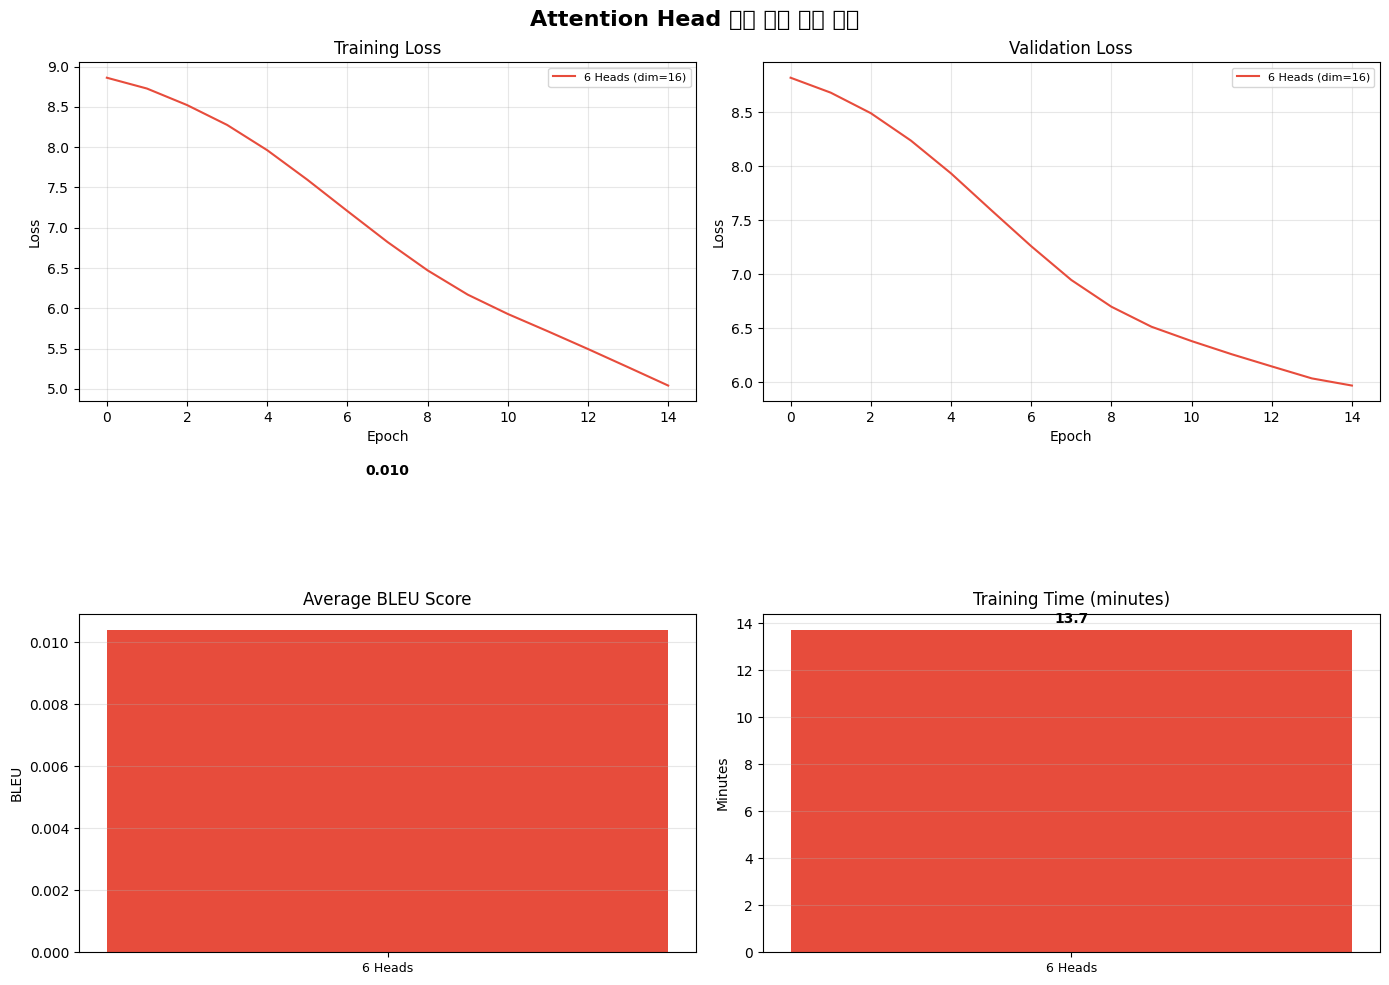


설정                     |   val_loss |    val_acc |     BLEU |    시간(분)
----------------------------------------------------------------------
6 Heads (dim=16)       |     5.9687 |     0.1466 |   0.0104 |     13.7


In [17]:
# Cell 16: [실험 B] 결과 시각화

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Attention Head 수에 따른 성능 비교', fontsize=16, fontweight='bold')
colors = ['#e74c3c', '#3498db', '#27ae60', '#f39c12']

# (1) Training Loss 곡선
ax = axes[0, 0]
for i, (name, r) in enumerate(results.items()):
    ax.plot(r['history']['loss'], color=colors[i], label=name, linewidth=1.5)
ax.set_title('Training Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (2) Validation Loss 곡선
ax = axes[0, 1]
for i, (name, r) in enumerate(results.items()):
    ax.plot(r['history']['val_loss'], color=colors[i], label=name, linewidth=1.5)
ax.set_title('Validation Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (3) BLEU Score 막대 그래프
ax = axes[1, 0]
names = list(results.keys())
bleus = [results[n]['avg_bleu'] for n in names]
bars  = ax.bar(range(len(names)), bleus, color=colors)
ax.set_title('Average BLEU Score')
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.split('(')[0].strip() for n in names], fontsize=9)
ax.set_ylabel('BLEU')
for bar, val in zip(bars, bleus):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# (4) 학습 시간 막대 그래프
ax = axes[1, 1]
times = [results[n]['train_time'] / 60 for n in names]
bars  = ax.bar(range(len(names)), times, color=colors)
ax.set_title('Training Time (minutes)')
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.split('(')[0].strip() for n in names], fontsize=9)
ax.set_ylabel('Minutes')
for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('exp_b_results.png', dpi=150, bbox_inches='tight')
plt.show()

# 요약 테이블
print(f"\n{'설정':<22} | {'val_loss':>10} | {'val_acc':>10} | {'BLEU':>8} | {'시간(분)':>8}")
print('-' * 70)
for name, r in results.items():
    print(f"{name:<22} | {r['best_val_loss']:>10.4f} | "
          f"{r['best_val_acc']:>10.4f} | {r['avg_bleu']:>8.4f} | "
          f"{r['train_time']/60:>8.1f}")

---
## 15. **[실험 A]** Attention Head 패턴 시각화

| 패턴       | 설명                  | 의미              |
|:----------:|:---------------------:|:-----------------:|
| 대각선     | 자기 자신에 집중      | positional 정보   |
| 인접 토큰  | 바로 앞/뒤 단어 집중  | 어순 관계         |
| 특정 토큰  | [START]/[END] 집중    | 문장 경계 인식    |
| 분산       | 여러 토큰에 고르게    | 문맥 전체 참조    |

분석 문장: "este e um problema que temos que resolver."

--- Encoder Layer 0 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'global_self_attention_3' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'encoder_layer_3' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


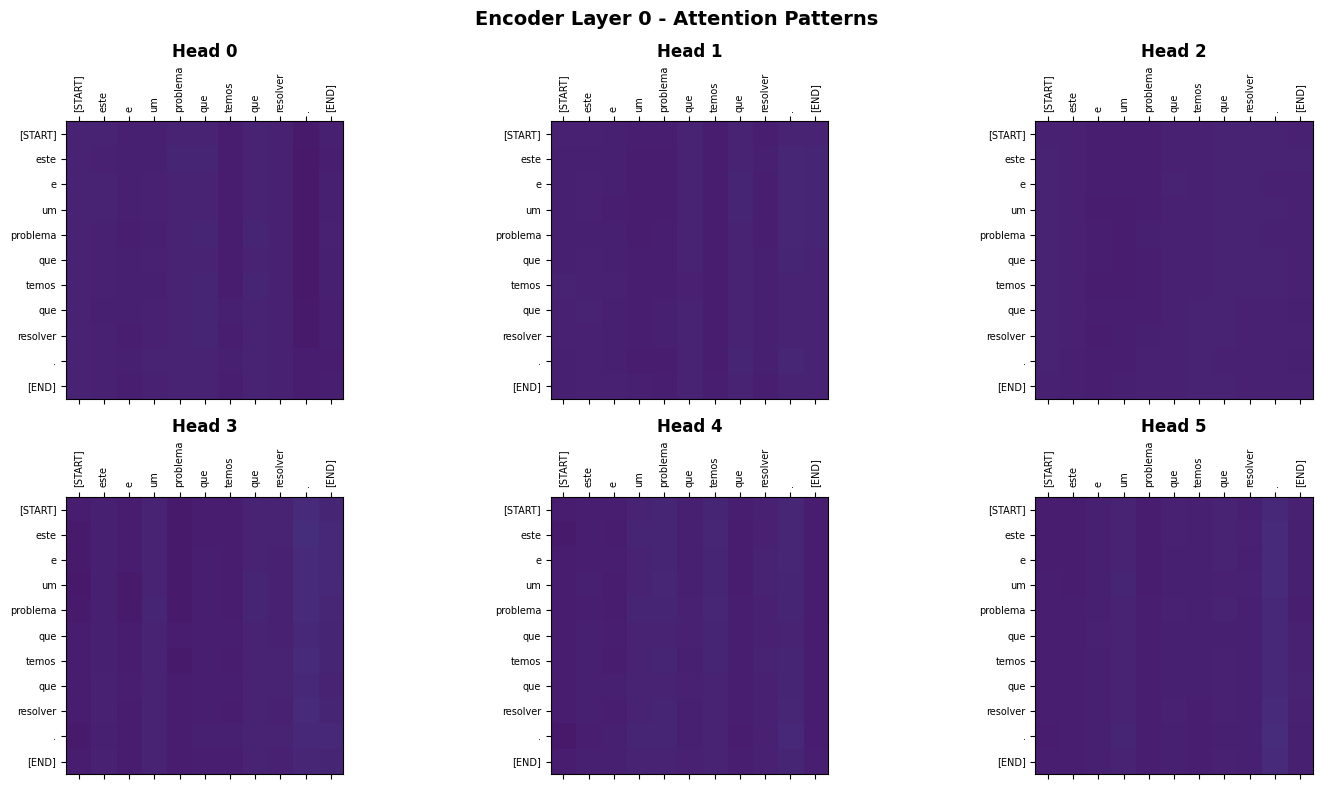

--- Encoder Layer 1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'global_self_attention_3' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'encoder_layer_3' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


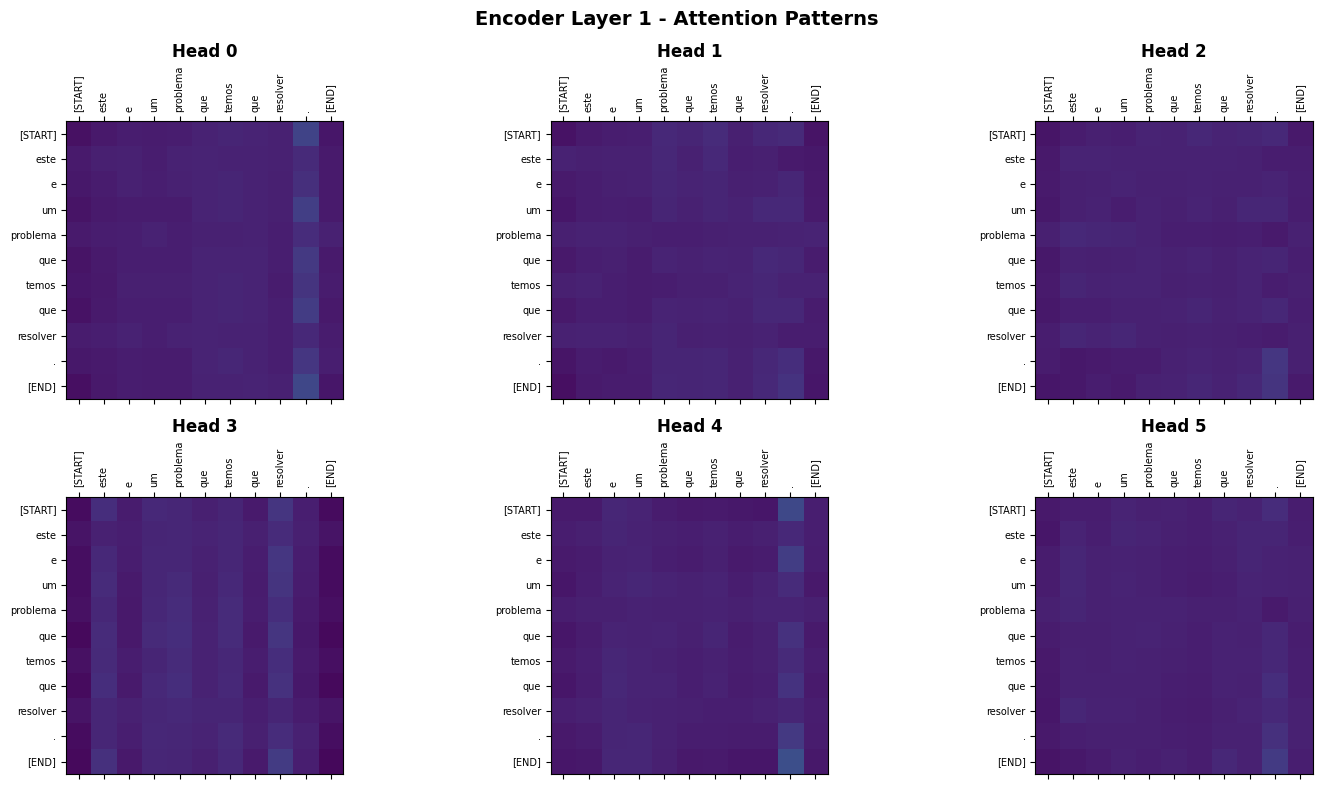

--- Encoder Layer 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'global_self_attention_3' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'encoder_layer_3' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


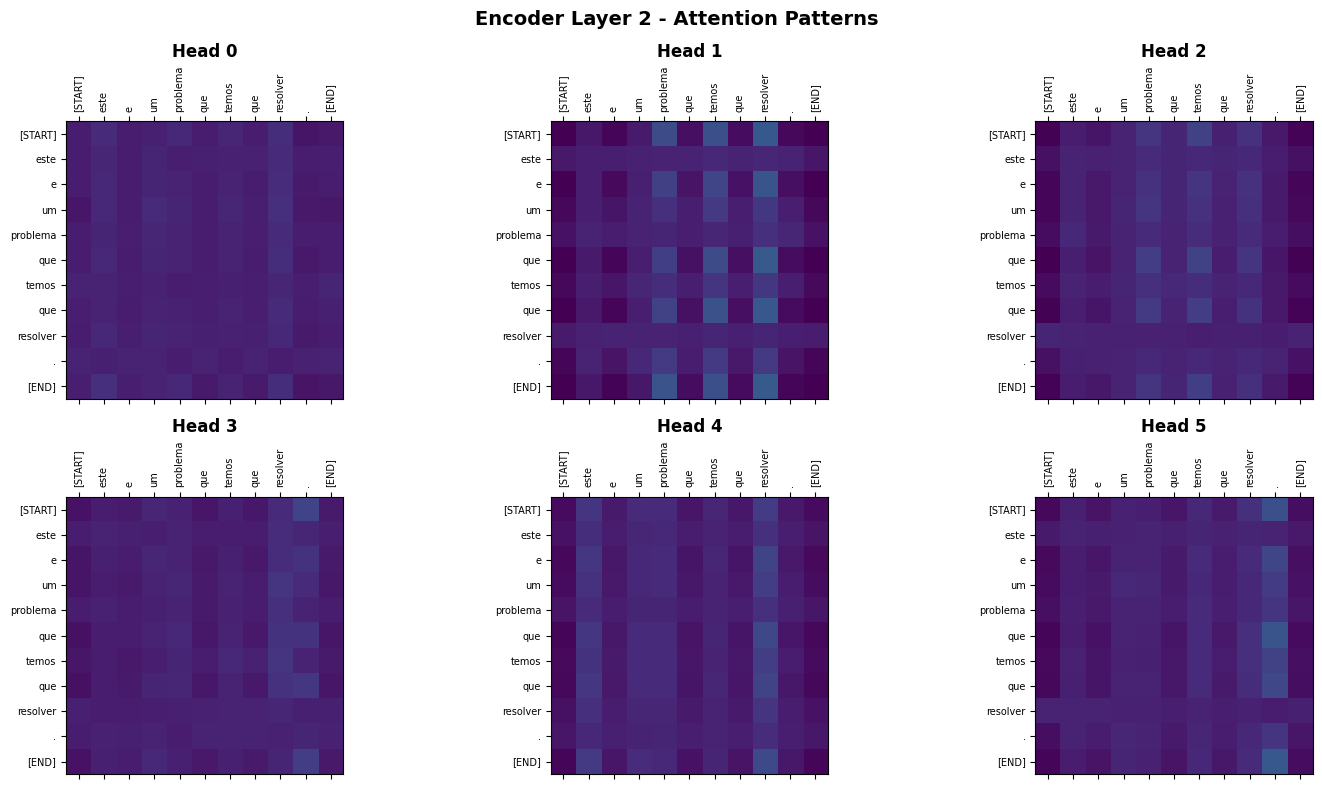

In [18]:
# Cell 17: [실험 A] Attention Head 패턴 시각화
# 6-Head 기본 모델의 각 Encoder layer별 Attention 패턴을 heatmap으로 시각화

base_model = results['6 Heads (dim=16)']['model']

def visualize_encoder_heads(model, sentence, tokenizers, layer_idx=0):
    # 1) 토큰화
    in_tokens = tokenizers.pt.tokenize(tf.constant([sentence])).to_tensor()
    # 2) Encoder 통과 → attention score 자동 저장
    _ = model.encoder(in_tokens, training=False)
    # 3) 해당 layer의 attention scores 추출
    attn = model.encoder.enc_layers[layer_idx].self_attention.last_attn_scores
    attn = tf.squeeze(attn, 0).numpy()  # (num_heads, seq, seq)
    # 4) 토큰 텍스트 변환
    token_labels = tokenizers.pt.lookup(in_tokens)[0].numpy()
    token_labels = [t.decode('utf-8') for t in token_labels]
    # 5) 시각화
    n_heads = attn.shape[0]
    cols = min(n_heads, 3)
    rows = (n_heads + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    if n_heads == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    for h in range(n_heads):
        ax = axes[h]
        ax.matshow(attn[h], cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f'Head {h}', fontsize=12, fontweight='bold')
        ax.set_xticks(range(len(token_labels)))
        ax.set_xticklabels(token_labels, rotation=90, fontsize=7)
        ax.set_yticks(range(len(token_labels)))
        ax.set_yticklabels(token_labels, fontsize=7)
    for h in range(n_heads, len(axes)):
        axes[h].set_visible(False)
    fig.suptitle(f'Encoder Layer {layer_idx} - Attention Patterns',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'attention_layer{layer_idx}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return attn

test_sent = 'este e um problema que temos que resolver.'
print(f'분석 문장: "{test_sent}"\n')

all_attn = {}
for layer_idx in range(3):  # num_layers = 3
    print(f'--- Encoder Layer {layer_idx} ---')
    all_attn[layer_idx] = visualize_encoder_heads(
        base_model, test_sent, tokenizers, layer_idx
    )

=== Attention Entropy 분석 ===
(높을수록 분산 패턴, 낮을수록 집중 패턴)

Encoder Layer 0:
  Head 0: entropy = 2.3927 (분산 패턴)
  Head 1: entropy = 2.3943 (분산 패턴)
  Head 2: entropy = 2.3965 (분산 패턴)
  Head 3: entropy = 2.3868 (집중 패턴)
  Head 4: entropy = 2.3916 (집중 패턴)
  Head 5: entropy = 2.3920 (집중 패턴)

Encoder Layer 1:
  Head 0: entropy = 2.3594 (집중 패턴)
  Head 1: entropy = 2.3811 (분산 패턴)
  Head 2: entropy = 2.3851 (분산 패턴)
  Head 3: entropy = 2.3235 (집중 패턴)
  Head 4: entropy = 2.3641 (집중 패턴)
  Head 5: entropy = 2.3857 (분산 패턴)

Encoder Layer 2:
  Head 0: entropy = 2.3811 (분산 패턴)
  Head 1: entropy = 2.1036 (집중 패턴)
  Head 2: entropy = 2.2713 (집중 패턴)
  Head 3: entropy = 2.3598 (분산 패턴)
  Head 4: entropy = 2.2776 (집중 패턴)
  Head 5: entropy = 2.2868 (분산 패턴)


=== Head 간 코사인 유사도 (Layer 0) ===


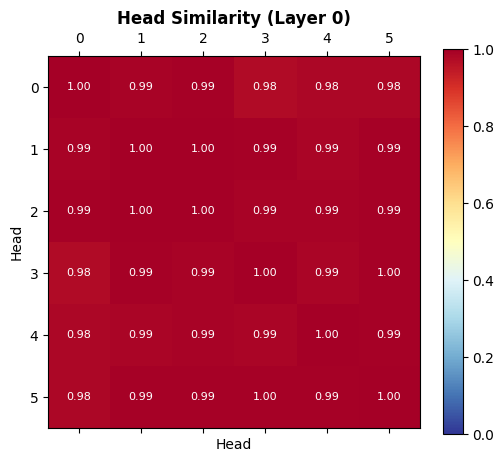


유사도가 높은 Head 쌍 (>0.8):
  Head 0 - Head 1: 0.990
  Head 0 - Head 2: 0.994
  Head 0 - Head 3: 0.976
  Head 0 - Head 4: 0.984
  Head 0 - Head 5: 0.982
  Head 1 - Head 2: 0.997
  Head 1 - Head 3: 0.993
  Head 1 - Head 4: 0.987
  Head 1 - Head 5: 0.995
  Head 2 - Head 3: 0.989
  Head 2 - Head 4: 0.991
  Head 2 - Head 5: 0.993
  Head 3 - Head 4: 0.986
  Head 3 - Head 5: 0.995
  Head 4 - Head 5: 0.993


In [19]:
# Cell 18: [실험 A] Attention Entropy 분석 및 Head 유사도
# Entropy 높음 → 분산 패턴 (여러 토큰에 고르게)
# Entropy 낮음 → 집중 패턴 (특정 토큰에 몰림)

def attention_entropy(attn_weights):
    """정보이론 기반 Attention 분포 엔트로피: -sum(p * log(p))"""
    eps     = 1e-10
    entropy = -np.sum(attn_weights * np.log(attn_weights + eps), axis=-1)
    return entropy.mean(axis=-1)  # (num_heads,)

def head_similarity(attn_weights):
    """Head 간 코사인 유사도 — 유사도 높은 쌍은 중복 후보"""
    n_heads   = attn_weights.shape[0]
    flat      = attn_weights.reshape(n_heads, -1)
    norms     = np.linalg.norm(flat, axis=1, keepdims=True) + 1e-10
    flat_norm = flat / norms
    return flat_norm @ flat_norm.T

# 엔트로피 출력
print('=== Attention Entropy 분석 ===')
print('(높을수록 분산 패턴, 낮을수록 집중 패턴)\n')
for layer_idx in range(3):
    entropy = attention_entropy(all_attn[layer_idx])
    print(f'Encoder Layer {layer_idx}:')
    for h, e in enumerate(entropy):
        pattern = '분산' if e > np.median(entropy) else '집중'
        print(f'  Head {h}: entropy = {e:.4f} ({pattern} 패턴)')
    print()

# Head 유사도 히트맵
print('\n=== Head 간 코사인 유사도 (Layer 0) ===')
sim = head_similarity(all_attn[0])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.matshow(sim, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_title('Head Similarity (Layer 0)', fontweight='bold')
ax.set_xlabel('Head'); ax.set_ylabel('Head')
plt.colorbar(im)
for i in range(sim.shape[0]):
    for j in range(sim.shape[1]):
        ax.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='black' if sim[i,j] < 0.7 else 'white')
plt.savefig('head_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n유사도가 높은 Head 쌍 (>0.8):')
for i in range(sim.shape[0]):
    for j in range(i+1, sim.shape[1]):
        if sim[i, j] > 0.8:
            print(f'  Head {i} - Head {j}: {sim[i,j]:.3f}')

---
## 16. **[실험 C]** Head Pruning

각 Head를 하나씩 0으로 마스킹 → val_loss 변화 측정  
→ 변화가 **작은** Head = 제거해도 무방한 **불필요한 Head**

In [20]:
# Cell 19: [실험 C] Head Pruning — 개별 Head 중요도 측정
# output projection 가중치에서 해당 Head 행(row)을 0으로 설정
# → 재학습 없이 각 Head의 기여도를 빠르게 측정

def evaluate_model(model, val_batches):
    res = model.evaluate(val_batches, verbose=0)
    return {'val_loss': res[0], 'val_acc': res[1]}

def mask_head(model, layer_idx, head_idx, num_heads, d_model):
    enc_layer = model.encoder.enc_layers[layer_idx]
    dense     = enc_layer.self_attention.mha._output_dense
    weights   = dense.get_weights()
    head_dim  = d_model // num_heads
    start, end = head_idx * head_dim, (head_idx + 1) * head_dim
    weights[0][start:end, :] = 0  # 해당 Head kernel을 0으로
    dense.set_weights(weights)

model      = results['6 Heads (dim=16)']['model']
NUM_HEADS  = 6
D_MODEL    = 96
NUM_LAYERS = 3

baseline = evaluate_model(model, val_batches)
print(f"Baseline — val_loss: {baseline['val_loss']:.4f}, val_acc: {baseline['val_acc']:.4f}")

print('\n=== Head별 중요도 측정 (마스킹 후 val_loss 변화) ===')
importance = {}
for layer_idx in range(NUM_LAYERS):
    print(f'\n--- Encoder Layer {layer_idx} ---')
    for head_idx in range(NUM_HEADS):
        enc_layer  = model.encoder.enc_layers[layer_idx]
        dense      = enc_layer.self_attention.mha._output_dense
        original_w = [w.copy() for w in dense.get_weights()]

        mask_head(model, layer_idx, head_idx, NUM_HEADS, D_MODEL)
        masked_result = evaluate_model(model, val_batches)
        loss_increase = masked_result['val_loss'] - baseline['val_loss']
        importance[(layer_idx, head_idx)] = loss_increase

        print(f'  Head {head_idx}: val_loss 변화 = +{loss_increase:.4f}')
        dense.set_weights(original_w)  # 복원

Baseline — val_loss: 5.9719, val_acc: 0.1456

=== Head별 중요도 측정 (마스킹 후 val_loss 변화) ===

--- Encoder Layer 0 ---
  Head 0: val_loss 변화 = +0.1353
  Head 1: val_loss 변화 = +-0.0030
  Head 2: val_loss 변화 = +0.0008
  Head 3: val_loss 변화 = +0.0003
  Head 4: val_loss 변화 = +-0.0026
  Head 5: val_loss 변화 = +0.0002

--- Encoder Layer 1 ---
  Head 0: val_loss 변화 = +-0.0113
  Head 1: val_loss 변화 = +0.0017
  Head 2: val_loss 변화 = +-0.0043
  Head 3: val_loss 변화 = +-0.0033
  Head 4: val_loss 변화 = +-0.0017
  Head 5: val_loss 변화 = +-0.0043

--- Encoder Layer 2 ---
  Head 0: val_loss 변화 = +-0.0106
  Head 1: val_loss 변화 = +-0.0018
  Head 2: val_loss 변화 = +-0.0042
  Head 3: val_loss 변화 = +-0.0002
  Head 4: val_loss 변화 = +-0.0056
  Head 5: val_loss 변화 = +-0.0033


Head 중요도 순위 (낮은순 = 제거 우선):
  1. Layer 1 Head 0: +-0.0113
  2. Layer 2 Head 0: +-0.0106
  3. Layer 2 Head 4: +-0.0056
  4. Layer 1 Head 2: +-0.0043
  5. Layer 1 Head 5: +-0.0043
  6. Layer 2 Head 2: +-0.0042
  7. Layer 1 Head 3: +-0.0033
  8. Layer 2 Head 5: +-0.0033
  9. Layer 0 Head 1: +-0.0030
  10. Layer 0 Head 4: +-0.0026
  11. Layer 2 Head 1: +-0.0018
  12. Layer 1 Head 4: +-0.0017
  13. Layer 2 Head 3: +-0.0002
  14. Layer 0 Head 5: +0.0002
  15. Layer 0 Head 3: +0.0003
  16. Layer 0 Head 2: +0.0008
  17. Layer 1 Head 1: +0.0017
  18. Layer 0 Head 0: +0.1353
Pruned 1/18 heads: val_loss=5.9629, val_acc=0.1440
Pruned 2/18 heads: val_loss=5.9545, val_acc=0.1466
Pruned 3/18 heads: val_loss=5.9570, val_acc=0.1497
Pruned 4/18 heads: val_loss=5.9583, val_acc=0.1476
Pruned 5/18 heads: val_loss=5.9557, val_acc=0.1479
Pruned 6/18 heads: val_loss=5.9554, val_acc=0.1482
Pruned 7/18 heads: val_loss=5.9450, val_acc=0.1453
Pruned 8/18 heads: val_loss=5.9393, val_acc=0.1547
Pruned 9/18 heads: va

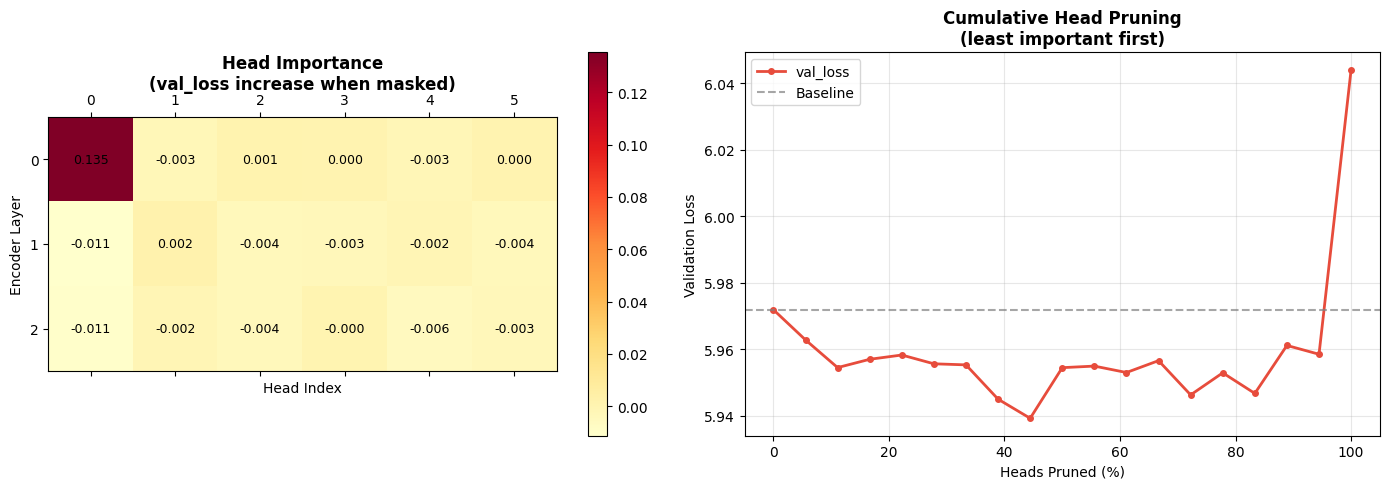

In [21]:
# Cell 20: [실험 C] Pruning 결과 시각화 — 히트맵 + 누적 제거 그래프

imp_matrix = np.zeros((NUM_LAYERS, NUM_HEADS))
for (l, h), val in importance.items():
    imp_matrix[l, h] = val

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) Head 중요도 히트맵
ax = axes[0]
im = ax.matshow(imp_matrix, cmap='YlOrRd')
ax.set_title('Head Importance\n(val_loss increase when masked)', fontweight='bold', pad=20)
ax.set_xlabel('Head Index'); ax.set_ylabel('Encoder Layer')
ax.set_xticks(range(NUM_HEADS)); ax.set_yticks(range(NUM_LAYERS))
plt.colorbar(im, ax=ax)
for i in range(NUM_LAYERS):
    for j in range(NUM_HEADS):
        ax.text(j, i, f'{imp_matrix[i,j]:.3f}', ha='center', va='center', fontsize=9)

# (2) 중요도 낮은 순 정렬 & 누적 제거
sorted_heads = sorted(importance.items(), key=lambda x: x[1])
print('Head 중요도 순위 (낮은순 = 제거 우선):')
for rank, ((l, h), imp) in enumerate(sorted_heads):
    print(f'  {rank+1}. Layer {l} Head {h}: +{imp:.4f}')

# 전체 원래 가중치 저장
all_original_weights = {}
for layer_idx in range(NUM_LAYERS):
    for head_idx in range(NUM_HEADS):
        enc_layer = model.encoder.enc_layers[layer_idx]
        dense     = enc_layer.self_attention.mha._output_dense
        all_original_weights[(layer_idx, head_idx)] = [w.copy() for w in dense.get_weights()]

# 전체 복원
for (l, h), w in all_original_weights.items():
    enc_layer = model.encoder.enc_layers[l]
    dense     = enc_layer.self_attention.mha._output_dense
    dense.set_weights(w)

cumulative_losses = [baseline['val_loss']]
cumulative_accs   = [baseline['val_acc']]
pruned_count      = [0]

for i, ((l, h), _) in enumerate(sorted_heads):
    mask_head(model, l, h, NUM_HEADS, D_MODEL)
    result = evaluate_model(model, val_batches)
    cumulative_losses.append(result['val_loss'])
    cumulative_accs.append(result['val_acc'])
    pruned_count.append(i + 1)
    print(f'Pruned {i+1}/{NUM_HEADS*NUM_LAYERS} heads: '
          f"val_loss={result['val_loss']:.4f}, val_acc={result['val_acc']:.4f}")

# 복원
for (l, h), w in all_original_weights.items():
    enc_layer = model.encoder.enc_layers[l]
    dense     = enc_layer.self_attention.mha._output_dense
    dense.set_weights(w)

# 누적 pruning 그래프
ax = axes[1]
total_heads = NUM_HEADS * NUM_LAYERS
x_pct = [n / total_heads * 100 for n in pruned_count]
ax.plot(x_pct, cumulative_losses, 'o-', color='#e74c3c',
        linewidth=2, markersize=4, label='val_loss')
ax.axhline(y=baseline['val_loss'], color='gray',
           linestyle='--', alpha=0.7, label='Baseline')
ax.set_title('Cumulative Head Pruning\n(least important first)', fontweight='bold')
ax.set_xlabel('Heads Pruned (%)'); ax.set_ylabel('Validation Loss')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('head_pruning_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 17. 전체 결과 저장

In [22]:
# Cell 21: 전체 결과 요약 및 JSON 저장

summary = {}
for name, r in results.items():
    summary[name] = {
        'num_heads':      r['num_heads'],
        'head_dim':       r['head_dim'],
        'best_val_loss':  float(r['best_val_loss']),
        'best_val_acc':   float(r['best_val_acc']),
        'avg_bleu':       float(r['avg_bleu']),
        'train_time_sec': float(r['train_time']),
    }

with open('experiment_results.json', 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('결과가 experiment_results.json에 저장되었습니다.')
print('\n' + '='*60)
print('실험 완료! 생성된 파일 목록:')
print('  - attention_layer0~2.png  (실험 A: Head 패턴)')
print('  - head_similarity.png     (실험 A: Head 유사도)')
print('  - exp_b_results.png       (실험 B: 성능 비교)')
print('  - head_pruning_results.png(실험 C: Pruning 결과)')
print('  - experiment_results.json (수치 결과)')
print('='*60)

결과가 experiment_results.json에 저장되었습니다.

실험 완료! 생성된 파일 목록:
  - attention_layer0~2.png  (실험 A: Head 패턴)
  - head_similarity.png     (실험 A: Head 유사도)
  - exp_b_results.png       (실험 B: 성능 비교)
  - head_pruning_results.png(실험 C: Pruning 결과)
  - experiment_results.json (수치 결과)
